In [ ]:
# This code is a slightly simplified version of the code in AR1121v2.ipynb.
# It only has the first six lags, but also includes data for day of the week and time of day.

# This program calculates the sensible load for Hewitt Hall Room 1121 every 15 minutes.

import numpy as np
import pandas as pd
from src import df_sanitizer
import matplotlib.pyplot as plt
import seaborn
import datetime
import statsmodels

df1121 = pd.read_csv(r"Data/Rm1121 - VMA13.csv")
df1121 = df_sanitizer.sanitize_df(df1121)
df1121_sensible_load = 1.08 * df1121["supply air flow"] * (df1121["zone temp"] - df1121["supply air temp"])
df1121_sensible_load.head()

ts
2022-11-04 00:15:00+00:00    3702.334110
2022-11-04 00:30:00+00:00   -7940.642403
2022-11-04 00:45:00+00:00   -8025.785816
2022-11-04 01:00:00+00:00   -7842.391521
2022-11-04 01:15:00+00:00    4625.440292
dtype: float64

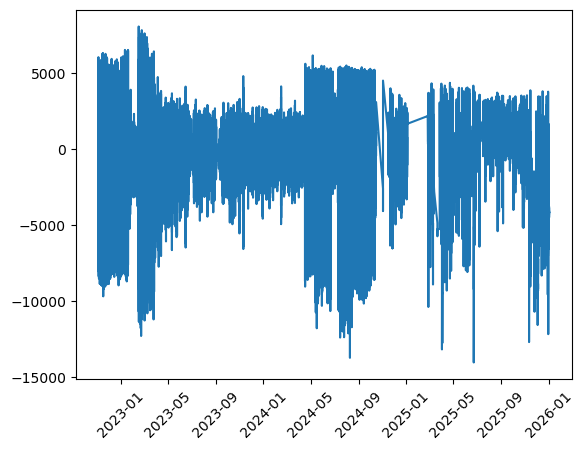

In [3]:
plt.plot(df1121_sensible_load)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Version 1 confirmed that the current sensible load is only correlated with the previous six time steps.
# We list the first six lags, then create a new dataframe with six additional columns.
# Each column is the sensible load shifted by a different number of time steps.

lags = [1, 2, 3, 4, 5, 6]

def create_lags(series, lags):
    df = series.to_frame(name="y").copy()
    for lag in lags:
        df[f"y_lag_{lag}"] = df["y"].shift(lag)
    return df

df_model = create_lags(df1121_sensible_load, lags)

df_model = df_model.dropna()

train_size = int(0.8 * len(df_model))

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]
df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6
ts,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292


In [ ]:
# We add new columns for the hours, minute, and day of the week.

df_model["hour"] = df_model.index.hour
df_model["minute"] = df_model.index.minute
df_model["dayofweek"] = df_model.index.dayofweek

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek
ts,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4


In [ ]:
# Create rolling statistics.
# These are the mean, standard deviation, minimum, and maximum of the previous 12, 24, and 48 time steps.

windows = [12, 24, 48]

for w in windows:
        df_model[f"roll_mean_{w}"] = df_model["y"].shift(1).rolling(w).mean()
        df_model[f"roll_std_{w}"] = df_model["y"].shift(1).rolling(w).std()
        df_model[f"roll_min_{w}"] = df_model["y"].shift(1).rolling(w).min()
        df_model[f"roll_max_{w}"] = df_model["y"].shift(1).rolling(w).max()

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,roll_min_12,roll_max_12,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_48,roll_std_48,roll_min_48,roll_max_48
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Eliminates all rows with missing values.

df_model = df_model.dropna()

In [ ]:
# Splits into training and testing sets. We use the first 80% of the data for training and the last 20% for testing.
# features is the list of all columns we use to predict future data and y is the column we want to predict.

features = df_model.columns.drop("y")

X = df_model[features] # What we will use to predict
y = df_model["y"] # What we want to predict

split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

ts_test = df_model.iloc[split:]

In [ ]:
# Uses XGBoost to train a regression model on the training data and then evaluates it on the testing data.

from xgboost import XGBRegressor

model = XGBRegressor(
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
pred = model.predict(X_test)

In [11]:
results = df_model.iloc[split:].copy()
results["prediction"] = pred

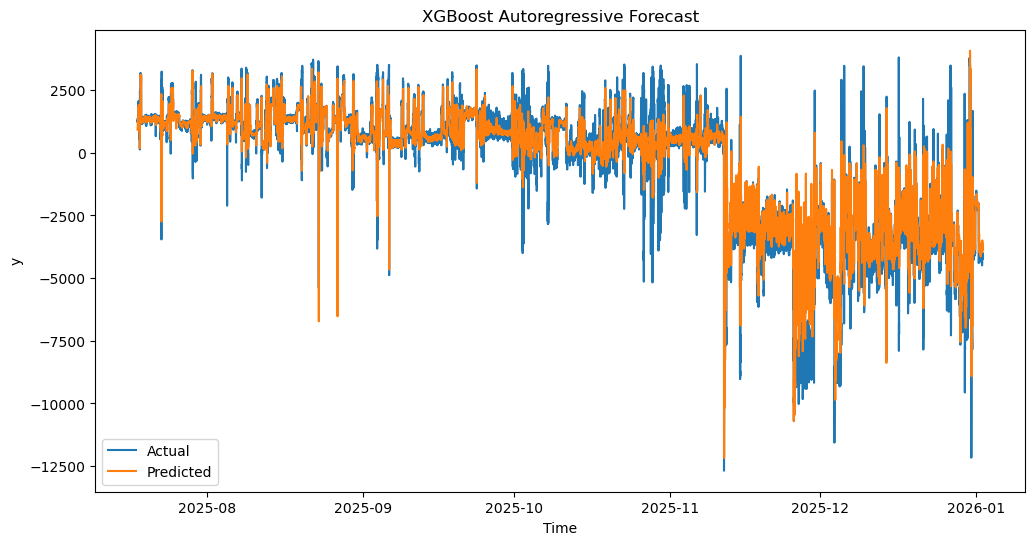

In [ ]:
# Plots the actual vs predicted values.

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(results.index, results["y"], label="Actual")
plt.plot(results.index, results["prediction"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

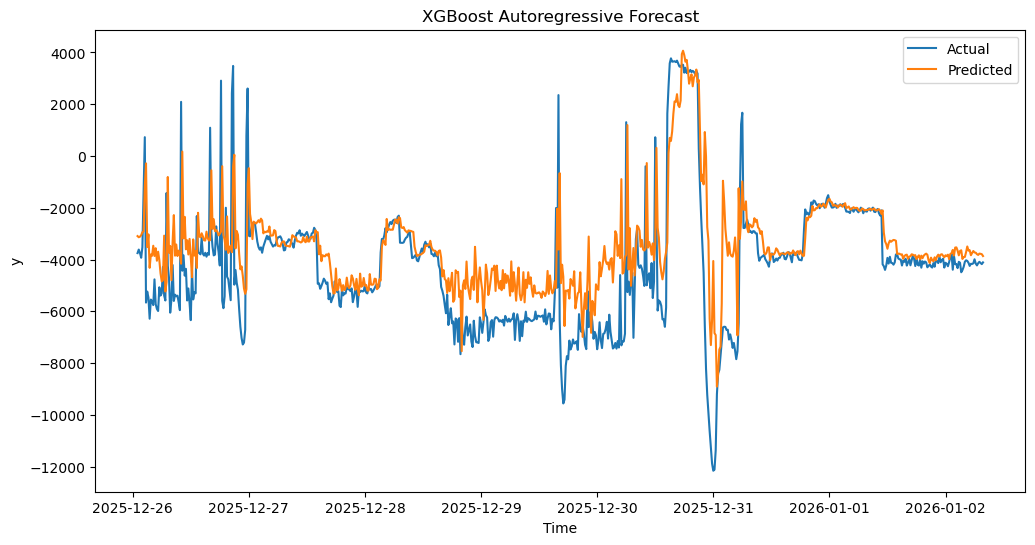

In [13]:
# Here is the output restricted to the final week of 2025.

plt.figure(figsize=(12,6))

plt.plot(results.index[-700:], results["y"][-700:], label="Actual")
plt.plot(results.index[-700:], results["prediction"][-700:], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

In [ ]:
# Finally, we calculate some evaluation metrics for the model.
# The model was 93.7% correlated with the actual results.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

corr = results["y"].corr(results["prediction"])
mae = mean_absolute_error(results["y"], results["prediction"])
rmse = np.sqrt(mean_squared_error(results["y"], results["prediction"]))
r2 = r2_score(results["y"], results["prediction"])

print("Correlation:", corr)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Correlation: 0.9368015378474424
MAE: 569.1324166554015
RMSE: 1035.5421352132068
R²: 0.8579888981232703
